#📌 Extracción

In [7]:
import pandas as pd
import json

file_path = "TelecomX_Data.json"

def cargar_datos_locales(ruta):
    try:
        with open(ruta, "r", encoding="utf-8") as f:
            datos = json.load(f)

        df = pd.DataFrame(datos)

        print("Datos cargados correctamente desde el archivo local.")
        print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
        return df

    except FileNotFoundError:
        print(f"Error: El archivo '{ruta}' no se encuentra en el entorno actual.")
        return None
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}")
        return None

df_telecom = cargar_datos_locales(file_path)

if df_telecom is not None:
    display(df_telecom.head())
    print("\nTipos de datos detectados:")
    df_telecom.info()

Datos cargados correctamente desde el archivo local.
Dimensiones: 7267 filas y 6 columnas.


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."



Tipos de datos detectados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#🔧 Transformación

In [9]:
# EXPLORACION INICIAL
print("### RESUMEN ESTADÍSTICO ###")
display(df_telecom.describe(include='all').T)

print("\n### DISTRIBUCIÓN DE CHURN ###")
print(df_telecom['Churn'].value_counts(normalize=True) * 100)

### RESUMEN ESTADÍSTICO ###


,count,unique,top,freq
customerID,7267,7267,9995-HOTOH,1
Churn,7267,3,No,5174
customer,7267,891,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...",223
phone,7267,3,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}",3495
internet,7267,129,"{'InternetService': 'No', 'OnlineSecurity': 'N...",1581
account,7267,6931,"{'Contract': 'Month-to-month', 'PaperlessBilli...",6



### DISTRIBUCIÓN DE CHURN ###
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [10]:
# Aplanar columnas anidadas
df_customer = pd.json_normalize(df_telecom['customer'])
df_phone = pd.json_normalize(df_telecom['phone'])
df_internet = pd.json_normalize(df_telecom['internet'])
df_account = pd.json_normalize(df_telecom['account'])

# Unir todo
df_limpio = pd.concat([
    df_telecom[['customerID', 'Churn']],
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

# Eliminar churn vacio
df_limpio = df_limpio[df_limpio['Churn'] != ""].copy()

# Correccion de tipos
df_limpio['tenure'] = df_limpio['tenure'].astype(int)

df_limpio['Charges.Monthly'] = pd.to_numeric(df_limpio['Charges.Monthly'], errors='coerce')

df_limpio['Charges.Total'] = pd.to_numeric(df_limpio['Charges.Total'], errors='coerce').fillna(0)

print("Dataset transformado correctamente")
display(df_limpio.head())

Dataset transformado correctamente


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


# Columna de cuentas diarias (Opcional)



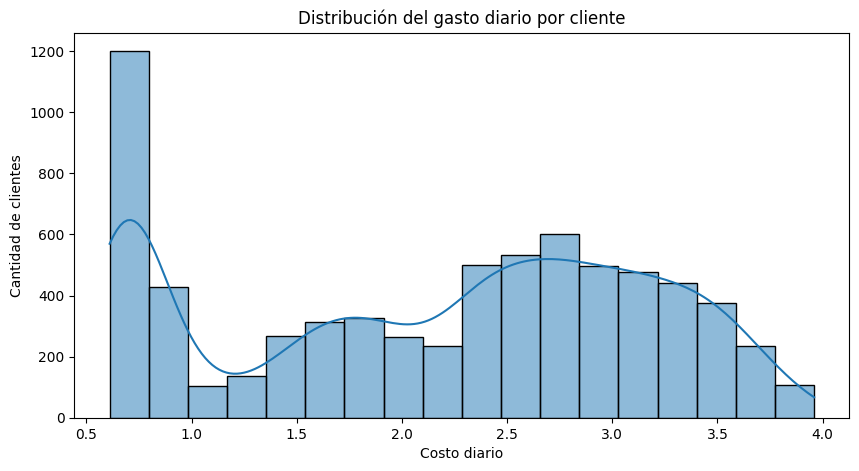

In [11]:
df_limpio['Cuentas_Diarias'] = (df_limpio['Charges.Monthly'] / 30).round(2)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(df_limpio['Cuentas_Diarias'], kde=True)

plt.title("Distribución del gasto diario por cliente")
plt.xlabel("Costo diario")
plt.ylabel("Cantidad de clientes")

plt.show()

# Estandarización y transformación de datos (opcional)

In [12]:
df_telecom_es = df_limpio.rename(columns={
'customerID':'ID_Cliente',
'Churn':'Abandono',
'gender':'Genero',
'SeniorCitizen':'Adulto_Mayor',
'Partner':'Tiene_Pareja',
'Dependents':'Tiene_Dependientes',
'tenure':'Meses_Contrato',
'Charges.Monthly':'Cargo_Mensual',
'Charges.Total':'Cargo_Total',
'Cuentas_Diarias':'Cargo_Diario'
})

df_telecom_es.head()

,ID_Cliente,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


#📊 Carga y análisis

## 1. Análisis descriptivo

In [13]:

# ANALISIS DESCRIPTIVO DEL DATASET

# 1. Estadisticas de variables numericas
print("Resumen estadístico de variables numéricas\n")

columnas_numericas = [
    'Meses_Contrato',
    'Cargo_Mensual',
    'Cargo_Total',
    'Cargo_Diario'
]

resumen_estadistico = df_telecom_es[columnas_numericas].describe()

display(resumen_estadistico)


# 2. Distribucion de variables categoricas relevantes
print("\nDistribución porcentual de variables categóricas clave")

variables_categoricas = [
    'Contract',
    'InternetService',
    'PaymentMethod'
]

for variable in variables_categoricas:
    distribucion = (
        df_telecom_es[variable]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print(f"\nDistribución de clientes según '{variable}':")
    print(distribucion)


# 3. Calculo de la tasa global de abandono
tasa_churn = (df_telecom_es['Abandono'] == 'Yes').mean() * 100

print("\nTasa general de abandono de clientes:")
print(f"{tasa_churn:.2f}% de los clientes han cancelado el servicio.")

Resumen estadístico de variables numéricas



,Meses_Contrato,Cargo_Mensual,Cargo_Total,Cargo_Diario
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158675
std,24.559481,30.090047,2266.794470,1.003088
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.500000,398.550000,1.180000
50%,29.000000,70.350000,1394.550000,2.340000
75%,55.000000,89.850000,3786.600000,2.990000
max,72.000000,118.750000,8684.800000,3.960000



Distribución porcentual de variables categóricas clave

Distribución de clientes según 'Contract':
Contract
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: proportion, dtype: float64

Distribución de clientes según 'InternetService':
InternetService
Fiber optic    43.96
DSL            34.37
No             21.67
Name: proportion, dtype: float64

Distribución de clientes según 'PaymentMethod':
PaymentMethod
Electronic check             33.58
Mailed check                 22.89
Bank transfer (automatic)    21.92
Credit card (automatic)      21.61
Name: proportion, dtype: float64

Tasa general de abandono de clientes:
26.54% de los clientes han cancelado el servicio.


## 2. Distribución de evasión:

/tmp/ipykernel_550/1376071774.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


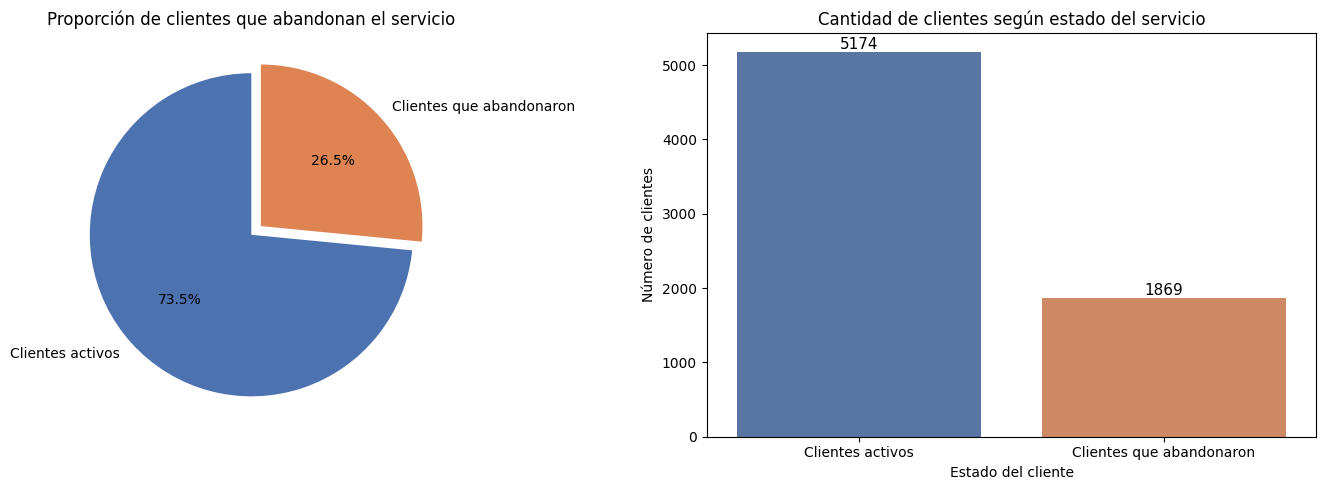

In [14]:
# DISTRIBUCION GENERAL DEL ABANDONO (CHURN)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Conteo de clientes por estado de abandono
conteo_churn = df_telecom_es['Abandono'].value_counts()

# Etiquetas para los gráficos
estados = ['Clientes activos', 'Clientes que abandonaron']

# Colores
paleta = ['#4C72B0', '#DD8452']


# 2. Configuracion de la figura
fig, axes = plt.subplots(1, 2, figsize=(14,5))


# --- Grafico 1: proporcion del abandono ---
axes[0].pie(
    conteo_churn.values,
    labels=estados,
    autopct='%1.1f%%',
    startangle=90,
    colors=paleta,
    explode=[0, 0.08]
)

axes[0].set_title("Proporción de clientes que abandonan el servicio")


# --- Grafico 2: cantidad absoluta de clientes ---
sns.barplot(
    x=estados,
    y=conteo_churn.values,
    palette=paleta,
    ax=axes[1]
)

axes[1].set_title("Cantidad de clientes según estado del servicio")
axes[1].set_ylabel("Número de clientes")
axes[1].set_xlabel("Estado del cliente")


# Agregar etiquetas numericas sobre las barras
for idx, valor in enumerate(conteo_churn.values):
    axes[1].text(idx, valor + 40, str(valor), ha='center', fontsize=11)


plt.tight_layout()
plt.show()

## 3. Recuento de evasión por variables categóricas

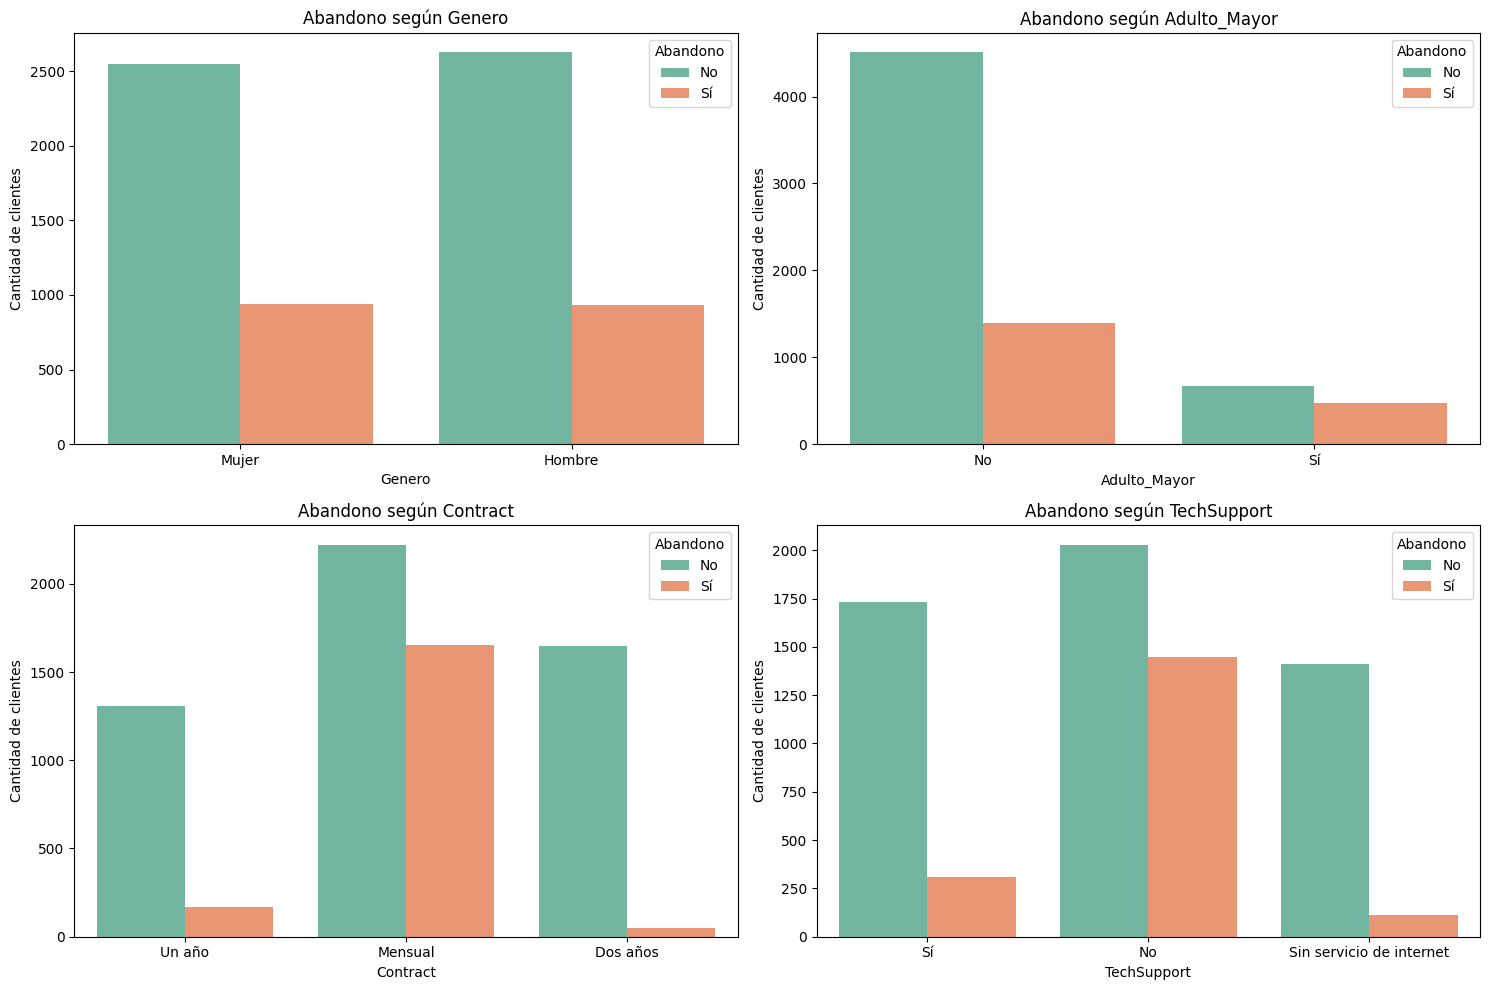

Porcentaje de abandono por tipo de contrato:

Contract
Mensual     42.71
Un año      11.27
Dos años     2.83
Name: Abandono, dtype: float64


In [16]:
# ABANDONO SEGUN VARIABLES CATEGORICAS

import matplotlib.pyplot as plt
import seaborn as sns

# Copia auxiliar para traducir etiquetas visibles en los graficos
df_cat = df_telecom_es.copy()

# Traduccion de valores
df_cat['Genero'] = df_cat['Genero'].replace({
    'Male': 'Hombre',
    'Female': 'Mujer'
})

df_cat['Adulto_Mayor'] = df_cat['Adulto_Mayor'].replace({
    0: 'No',
    1: 'Sí'
})

df_cat['Contract'] = df_cat['Contract'].replace({
    'Month-to-month': 'Mensual',
    'One year': 'Un año',
    'Two year': 'Dos años'
})

df_cat['TechSupport'] = df_cat['TechSupport'].replace({
    'Yes': 'Sí',
    'No': 'No',
    'No internet service': 'Sin servicio de internet'
})

df_cat['Abandono'] = df_cat['Abandono'].replace({
    'Yes': 'Sí',
    'No': 'No'
})

variables_cat = ['Genero', 'Adulto_Mayor', 'Contract', 'TechSupport']

fig, graficos = plt.subplots(2, 2, figsize=(15,10))
graficos = graficos.flatten()

for i, variable in enumerate(variables_cat):

    sns.countplot(
        data=df_cat,
        x=variable,
        hue='Abandono',
        palette='Set2',
        ax=graficos[i]
    )

    graficos[i].set_title(f'Abandono según {variable}')
    graficos[i].set_xlabel(variable)
    graficos[i].set_ylabel('Cantidad de clientes')

plt.tight_layout()
plt.show()


# PORCENTAJE DE ABANDONO SEGÚN TIPO DE CONTRATO


print("Porcentaje de abandono por tipo de contrato:\n")

tabla_contrato = df_cat.copy()

porcentaje_churn_contrato = (
    tabla_contrato
    .groupby('Contract')['Abandono']
    .apply(lambda x: (x == 'Sí').mean() * 100)
)

print(porcentaje_churn_contrato.sort_values(ascending=False).round(2))

## 4. Conteo de evasión por variables numéricas

/tmp/ipykernel_550/3238216804.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_550/3238216804.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_550/3238216804.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_550/3238216804.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


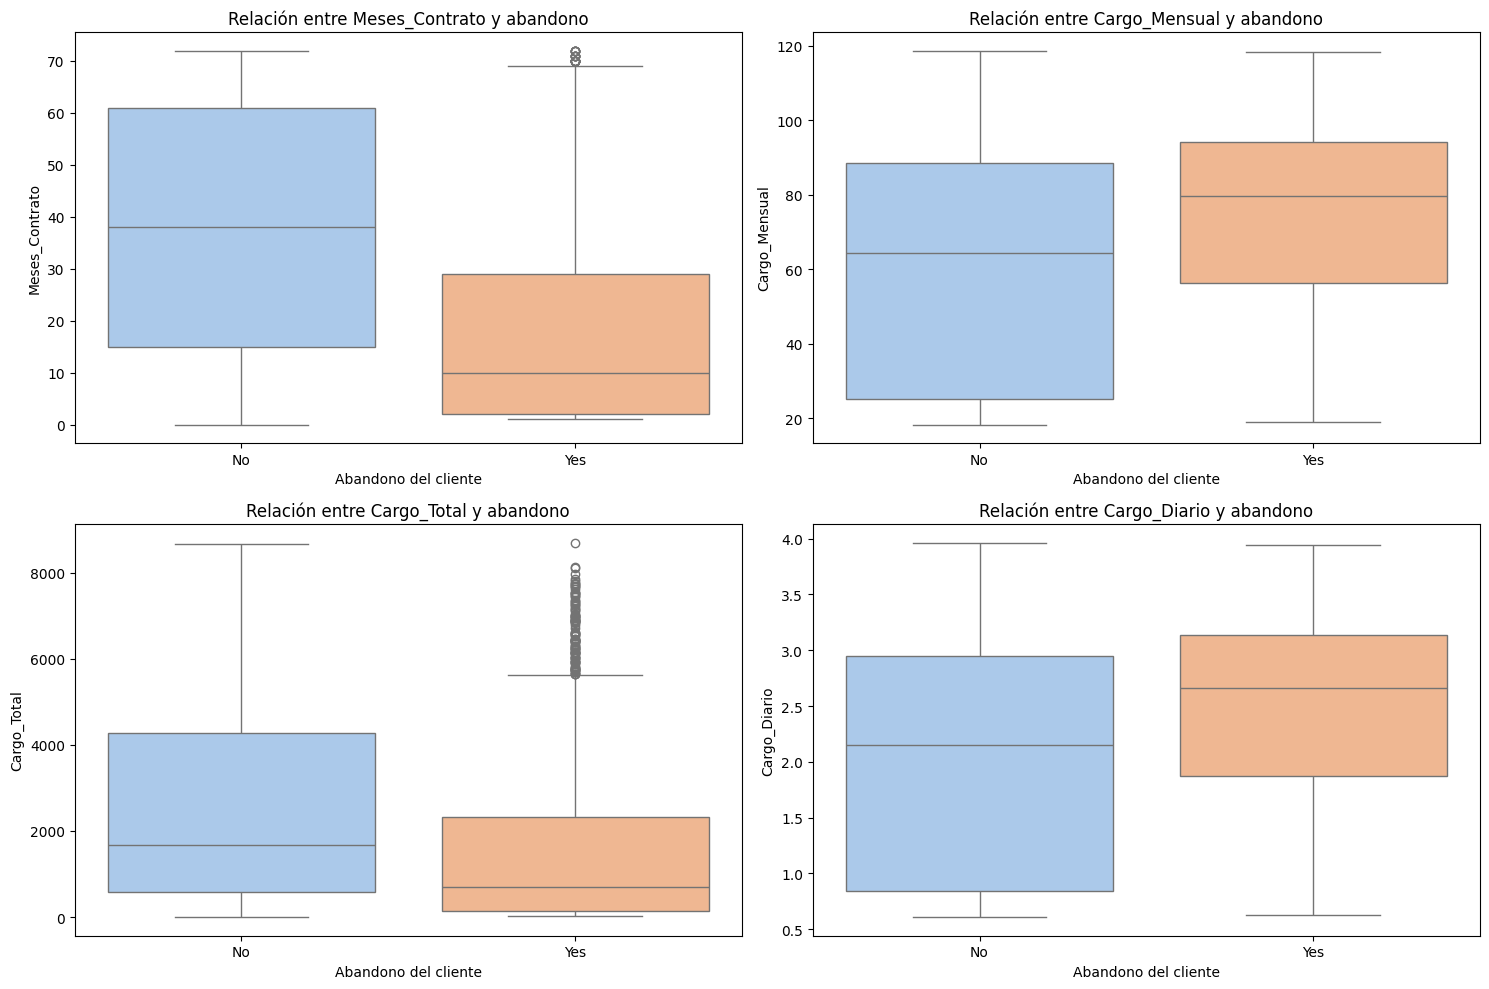

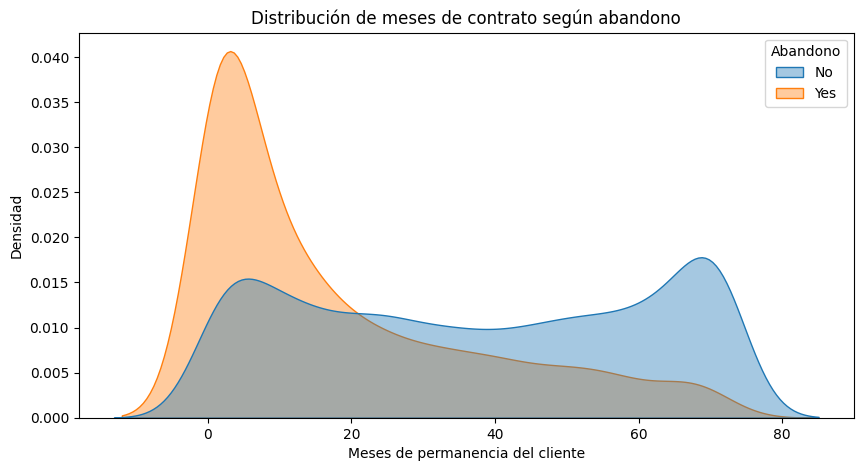

In [17]:
# =========================================
# ABANDONO SEGÚN VARIABLES NUMÉRICAS
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Variables numéricas a analizar
columnas_numericas = ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']

# Crear figura con 4 gráficos
fig, ejes = plt.subplots(2, 2, figsize=(15,10))
ejes = ejes.flatten()

for i, columna in enumerate(columnas_numericas):

    sns.boxplot(
        data=df_telecom_es,
        x='Abandono',
        y=columna,
        palette='pastel',
        ax=ejes[i]
    )

    ejes[i].set_title(f'Relación entre {columna} y abandono')
    ejes[i].set_xlabel('Abandono del cliente')
    ejes[i].set_ylabel(columna)

plt.tight_layout()
plt.show()


# =========================================
# DISTRIBUCIÓN DE ANTIGÜEDAD DEL CLIENTE
# =========================================

plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df_telecom_es,
    x='Meses_Contrato',
    hue='Abandono',
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title('Distribución de meses de contrato según abandono')
plt.xlabel('Meses de permanencia del cliente')
plt.ylabel('Densidad')

plt.show()

#📄Informe final

# Análisis de evasión de clientes (Churn) — Telecom X


---



## 🧭 1. Introducción

El abandono de clientes (Churn) representa uno de los principales desafíos en empresas de telecomunicaciones. Cuando un cliente cancela su servicio, la compañía no solo pierde ingresos futuros, sino que además debe invertir recursos adicionales en la adquisición de nuevos clientes para compensar dicha pérdida.

El objetivo de este análisis es identificar patrones y variables que estén asociadas con el abandono de clientes en Telecom X. A partir de un análisis exploratorio de datos (EDA), se busca comprender cómo factores como:


*   📅 Antigüedad del clienteElemento de la lista
*   💰 Costo del servicio
*   📑 Tipo de contratoElemento de la lista
*   🛠 Servicios adicionalesElemento de la lista



influyen en la probabilidad de cancelación.

Los resultados obtenidos permitirán generar insights accionables que puedan ser utilizados posteriormente para diseñar estrategias de retención de clientes.

## 🧹 2. Preparación y limpieza de datos

Antes de realizar el análisis fue necesario realizar un proceso de preparación y transformación de los datos para garantizar su consistencia y calidad.

###**📥 Extracción de datos**

El dataset fue proporcionado en formato JSON, el cual contenía información estructurada en forma de diccionarios anidados. Esto implicó realizar un proceso de normalización para convertir los datos en una estructura tabular adecuada para el análisis.


###**🔧 Aplanamiento de datos (Flattening)**

Las columnas que contenían estructuras anidadas (customer, phone, internet, account) fueron separadas en múltiples columnas utilizando técnicas de normalización, generando un dataset plano que permite realizar análisis estadísticos y visualizaciones.


###**⚠️ Tratamiento de inconsistencias**

Durante el proceso de exploración se identificaron registros con valores vacíos en la variable Churn.

Estos registros fueron eliminados para evitar inconsistencias en el análisis.


###**🔢 Conversión de tipos de datos**

Algunas variables originalmente estaban almacenadas como texto y fueron convertidas a formatos numéricos para permitir cálculos estadísticos:

tenure → entero

Charges.Monthly → float

Charges.Total → float


###**➕ Creación de nuevas variables**

Se creó una nueva variable denominada Cargo_Diario, calculada a partir del cargo mensual:

Cargo_Diario = Cargo_Mensual / 30

Esta variable permite observar con mayor detalle el comportamiento de gasto de los clientes.

## 🔎 3. Análisis exploratorio de datos (EDA)

A partir del análisis descriptivo y visualización de los datos se identificaron varios patrones relevantes.

###**📉 Distribución general de abandono**

El análisis mostró que aproximadamente 26.5% de los clientes abandonan el servicio.

Esto representa una proporción considerable de la base total de usuarios y evidencia una oportunidad significativa para mejorar las estrategias de retención.

###**📑 Impacto del tipo de contrato**

Uno de los factores más influyentes observados fue el tipo de contrato.

Los clientes con contratos mensuales ("Month-to-month") presentan una tasa de abandono considerablemente mayor que aquellos con contratos de uno o dos años.

**💡 Esto indica que los contratos de largo plazo generan mayor estabilidad y reducen la probabilidad de cancelación.**

###**⏳ Antigüedad del cliente (Meses de contrato)**

Los gráficos de densidad y boxplots muestran que los clientes que abandonan el servicio suelen tener pocos meses de permanencia.

En cambio, los clientes que permanecen en la empresa suelen tener una antigüedad significativamente mayor.

**⚠️ Esto sugiere que el riesgo de abandono es más alto durante los primeros meses de relación con el cliente.**

###**💰 Costo del servicio**

El análisis de las variables financieras muestra que los clientes que abandonan el servicio tienden a tener cargos mensuales más altos en promedio.

**Esto puede indicar que algunos clientes perciben que el costo del servicio es elevado en relación al valor recibido.**

Por otro lado, los clientes que permanecen suelen presentar mayores cargos totales, lo cual se explica por una mayor permanencia en la empresa.

###**🛠 Servicios adicionales**

El análisis también muestra que los clientes que no cuentan con soporte técnico presentan una mayor tasa de abandono.

Esto sugiere que los servicios de soporte y asistencia técnica pueden actuar como factores que aumentan la satisfacción del cliente y reducen la probabilidad de cancelación.

## 📌 4. Conclusiones principales

A partir del análisis realizado se identificaron varios factores asociados al abandono de clientes:

🔹 Clientes nuevos presentan mayor riesgo de abandono
Los primeros meses de servicio representan el período más crítico para la retención.

🔹 Los contratos mensuales presentan mayor churn
Los clientes sin compromiso de permanencia tienen mayor probabilidad de cancelar el servicio.

🔹 Los costos más altos están asociados a mayor abandono
Los clientes con cargos mensuales más elevados tienden a cancelar con mayor frecuencia.

🔹 Los servicios de soporte aumentan la retención
Los clientes que cuentan con soporte técnico presentan menor tasa de abandono.

## 🚀 5. Recomendaciones estratégicas

A partir de los resultados del análisis se proponen las siguientes estrategias:

###**🎯 Programas de retención temprana**

Implementar estrategias de fidelización durante los primeros meses de servicio, cuando el riesgo de abandono es mayor.

Por ejemplo:

seguimiento activo del cliente

soporte técnico prioritario

beneficios de bienvenida

###**📑 Incentivar contratos de largo plazo**

Promover la migración desde contratos mensuales hacia contratos de 1 o 2 años mediante incentivos como:

descuentos

beneficios adicionales

mejoras en el servicio

###**💲 Optimización de la estrategia de precios**

Analizar los planes con cargo mensual más elevado para evaluar si el valor percibido por el cliente corresponde con el precio pagado.

Esto podría incluir:



*   Revisión de precios
*   Mejora de beneficios incluidos
*   Paquetes de servicios más competitivos
*   Promoción de servicios de soporteElemento de la lista



Fomentar el uso de servicios como:

* TechSupport

* OnlineSecurity

Estos servicios parecen contribuir a una mayor permanencia del cliente.

##**🧠 Conclusión final**

El análisis exploratorio permitió identificar variables clave que influyen en el abandono de clientes en Telecom X.

Comprender estos patrones es el primer paso para desarrollar modelos predictivos de churn y diseñar estrategias efectivas de retención, permitiendo mejorar la estabilidad y rentabilidad de la base de clientes.